In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

In [2]:
loan_data = pd.DataFrame({
    "Income": [25, 30, 45, 50, 60, 70, 80, 90, 35, 40, 55, 75],
    "CreditScore": [580, 600, 650, 670, 700, 720, 750, 780, 610, 640, 690, 740],
    "LoanAmount": [20, 25, 30, 35, 40, 45, 50, 55, 28, 32, 38, 48],
    "Age": [22, 25, 30, 35, 40, 45, 50, 55, 27, 32, 38, 48],
    "Approved": [0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1]
})

loan_data.to_csv("loan_approval.csv", index=False)

print("Loan dataset created successfully!")
print(loan_data)

Loan dataset created successfully!
    Income  CreditScore  LoanAmount  Age  Approved
0       25          580          20   22         0
1       30          600          25   25         0
2       45          650          30   30         0
3       50          670          35   35         1
4       60          700          40   40         1
5       70          720          45   45         1
6       80          750          50   50         1
7       90          780          55   55         1
8       35          610          28   27         0
9       40          640          32   32         0
10      55          690          38   38         1
11      75          740          48   48         1


In [3]:
X = loan_data[["Income", "CreditScore", "LoanAmount", "Age"]]
y = loan_data["Approved"]

print("Features:")
print(X)

print("\nTarget:")
print(y)

Features:
    Income  CreditScore  LoanAmount  Age
0       25          580          20   22
1       30          600          25   25
2       45          650          30   30
3       50          670          35   35
4       60          700          40   40
5       70          720          45   45
6       80          750          50   50
7       90          780          55   55
8       35          610          28   27
9       40          640          32   32
10      55          690          38   38
11      75          740          48   48

Target:
0     0
1     0
2     0
3     1
4     1
5     1
6     1
7     1
8     0
9     0
10    1
11    1
Name: Approved, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (9, 4)
Testing data: (3, 4)


In [5]:
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Decision Tree trained successfully!")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree trained successfully!
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



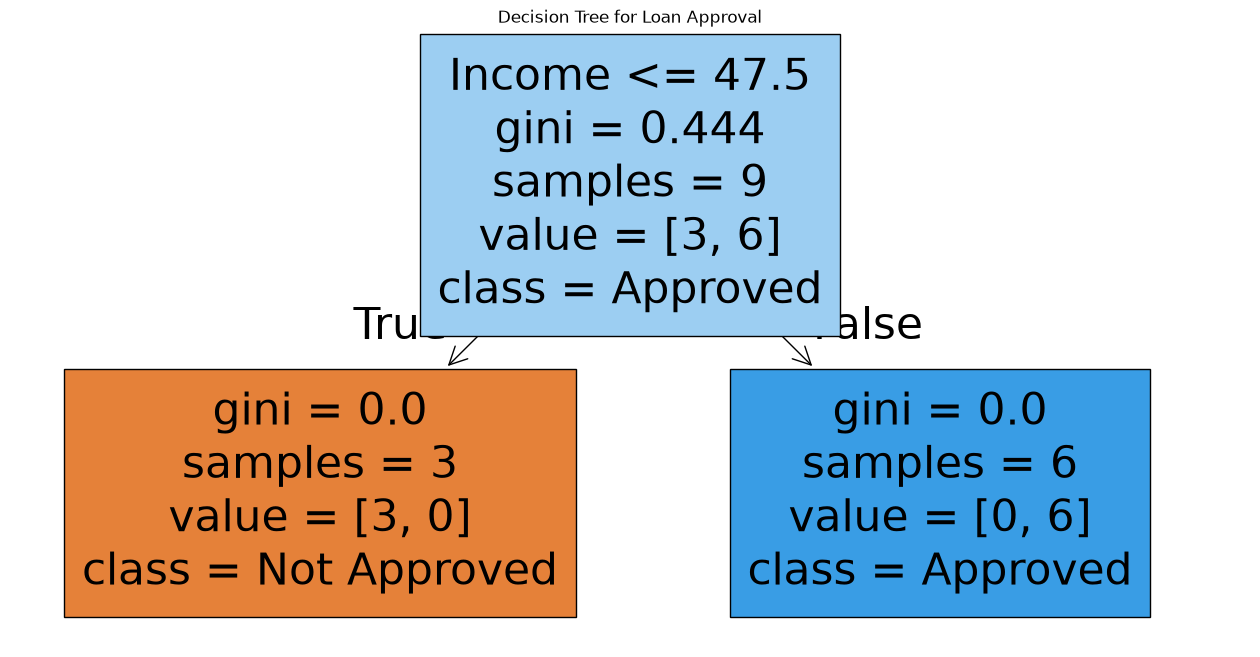

In [6]:
plt.figure(figsize=(16, 8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Approved", "Approved"],
    filled=True
)

plt.title("Decision Tree for Loan Approval")
plt.show()

In [7]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

       Feature  Importance
0       Income         1.0
1  CreditScore         0.0
2   LoanAmount         0.0
3          Age         0.0


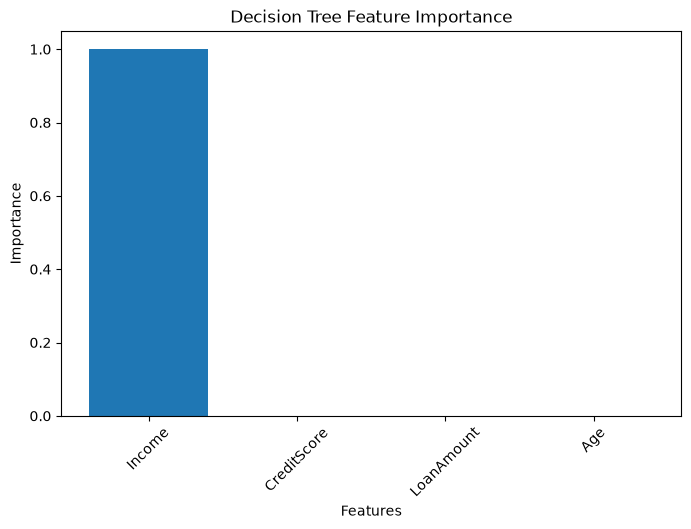

In [8]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [9]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("Accuracy Gap:", train_accuracy - test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 1.0
Accuracy Gap: 0.0


In [11]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)[0]

print("Sample:")
print(sample)

print("Predicted Decision:",
      "Approved" if prediction == 1 else "Not Approved")

Sample:
    Income  CreditScore  LoanAmount  Age
10      55          690          38   38
Predicted Decision: Approved


In [12]:
feature_importance.to_csv("loan_feature_importance.csv", index=False)

print("Feature importance saved successfully!")

Feature importance saved successfully!
